<div style="background: #1f2933; padding: 30px; border-radius: 14px; text-align: center; color: #f9fafb; box-shadow: 0px 4px 12px rgba(0,0,0,0.15); border-left: 5px solid #85e0e9ff;">

<h1 style="margin-bottom: 10px;">
📊 Exercise project 5 ADVANCE (PART1-2) – KNN REGRESSOR
</h1>

<h3 style="margin-top: 0; font-weight: 400; color: #fde68a;">
ML Model: Energy Consumption
</h3>

</div>



<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset name:</b>
</h4>

<a href="https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression" 
   target="_blank"
   style="font-size:16px; color:#fde68a; text-decoration:none;">
Energy Consumption Dataset 
</a>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset format:</b>
</h4>

<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Single CSV
</p>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

  <h4 style="margin:0; color:#f9fafb;">
    <b>Data description</b>
  </h4>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    This dataset is built for predicting building energy consumption. 
    Each row represents a building record with structural and environmental features that affect electricity usage.
  </p>

  <ul style="margin:6px 0 0 18px; padding:0; font-size:16px; color:#fde68a;">
    <li><b>Building Type</b></li>
    <li><b>Square Footage</b></li>
    <li><b>Number of Occupants</b></li>
    <li><b>Number of Appliances</b></li>
    <li><b>Average Temperature</b></li>
    <li><b>Day of Week</b></li>
    <li><b>Energy Consumption</b> (Target)</li>
  </ul>

</div>

<div style="background-color: #fff3cd; border: 2px solid #ffc107; padding: 15px; border-radius: 8px; margin: 20px 0;">
    <h3 style="color: #856404; margin-top: 0;">⚠️ Before You Start</h3>
    <p style="color: #856404; margin-bottom: 0;">
        <strong>Remember:</strong> Run each cell in order by clicking inside it and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd>. Don't skip ahead!
    </p>
</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 1 - Loading the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Code: Importing modules, custom functions and loading the data
</p>
</div>


<h3>
<strong style='color:orange ;'> SVM Regression and AUTOMATIC SCALING
 </strong>
</h3>




In [1]:
# Loading the required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importing helpful features like pipelines etc, also SVM!
from sklearn.model_selection import train_test_split
from sklearn import metrics, svm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# this module makes our life EASIER
# combine this with Pipelines => both X and y -scaling can be automated!
from sklearn.compose import TransformedTargetRegressor


# import pipelines, SVM etc.
from sklearn.model_selection import train_test_split
from sklearn import metrics, svm

# regression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn import svm

In [2]:
# loading the data
df = pd.read_csv("test_energy_data.csv")
df


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59
...,...,...,...,...,...,...,...
95,Commercial,1161,81,11,15.45,Weekend,3010.81
96,Residential,37943,50,23,21.73,Weekend,4248.49
97,Commercial,1558,27,29,16.86,Weekend,2843.60
98,Industrial,2145,56,12,11.77,Weekend,3348.39


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> 🔬 STEP 2 - Exploring  the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
   Code: Basic data checks, duplicates or missing values (NaN)?
</div>

In [3]:
# let's quickly see the first 5 rows of data
df.head(5)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


In [4]:
# printing total no.s of rows and columns of whole dataset
df.shape

(100, 7)

In [5]:
# checking column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


In [6]:
# getting statistical summary of the dataframe
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,25881.920000,47.230000,26.970000,22.043300,4187.57830
std,13711.075264,29.905526,14.237846,6.957951,832.55985
min,1161.000000,2.000000,1.000000,10.400000,2351.97000
25%,14161.000000,21.000000,16.750000,15.682500,3621.92500
50%,27582.500000,47.000000,27.500000,21.970000,4249.39000
75%,38109.500000,73.000000,39.250000,27.492500,4797.17500
max,49354.000000,99.000000,49.000000,34.710000,6042.56000


---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Cleaning</b>
</h2>
</div>


<h3>
<strong style='color:orange ;'>Handling missing/duplicate values and 
HANDLE ALL CATEGORICAL VARIABLES CORRECTLY
 </strong>
</h3>




<h3>
<strong style='color:orange ;'>Data cleanup procedure and getting the ready data for training the Ml model
 </strong>
</h3>




In [7]:
# checking the nan values in the dataset
df.isna().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [8]:
# do we have duplicates in the dataset
duplicates = int(df.duplicated().sum())
duplicates

0

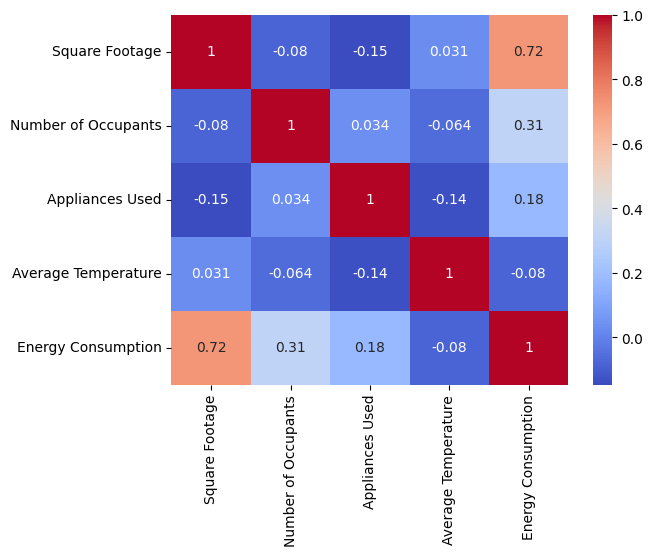

In [9]:
# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# plotting the correlation matrix using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

<div style="border: 4px solid #85e0e9ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
     OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The dataset has <b>100 rows</b> and <b>7 columns</b>.</li>
    <li>There is not any null values in the dataset or duplicates in the dataset.</li>
    <li>Most columns are numeric .</li>
    <li><b>Square Footage and Energy Consumption</b> show a strong positive correlation of <b>0.72</b>. Bigger homes tend to use more energy. This is the strongest relationship in the dataset.</li>

  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Preparation</b>
</h2>
</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b> HANDLING ALL CATEGORICAL VARIABLES CORRECTLY</b>
</h4>
</div>


<h3>
<strong style='color:orange ;'>Case 1: Binary variables (only two options)
 </strong>
</h3>

In [10]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time

from sklearn.preprocessing import LabelEncoder
variables = ['Day of Week']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

<h3>
<strong style='color:orange ;'>Case 2: Ordinal variables (categories that have an order/rank -> can be compared)
</strong>
</h3>




In [11]:
# converting the categorical variable "Building Type" 
# to numerical values using mapping

cut_mapping = { "Residential": 1,
                "Industrial": 2,
                "Commercial": 3, 
                }

df['Building Type'] = df['Building Type'].map(cut_mapping)

<div style="border: 4px solid #85e0e9ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>There is only <b>one column</b> with <b>two unique values</b>, so I treated it as a <b>binary variable</b> and converted it into <b>0</b> and <b>1</b>.</li>
    <li>There is <b>one column</b> with <b>three distinct values</b>  so I treated it as an <b>ordinal variable</b> and mapped the categories into numbers.</li>
    <li>After these steps, all important columns are in <b>numeric format</b>, which is needed before training a machine learning model.</li>
  </ul>
</div>

---

<div style="border: 4px solid #c63d10ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    Till here everything is same like SVM model in ex3 for this dataset. 
  </h2>


</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 3: X/y and train/test -split</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Data preparation as X and Y</b>
</h3>


In [12]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Energy Consumption", axis=1)

# our target variable is y
y = df["Energy Consumption"]

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>


In [13]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=142)

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: Training the X and the y split
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    I have used the 30 70 split for this model

  </p>

</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 4: Create and train the ML model</b>
</h3>
</div>


In [14]:
# pipeline: polynomial -> scaling -> SVR
pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    svm.LinearSVR()
)

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    CODE INSIGHT: 
  </h2>

  <ul style="margin:0 0 0 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>I used PolynomialFeatures because there were some outliers after training.</li>
  </ul>

</div>

3


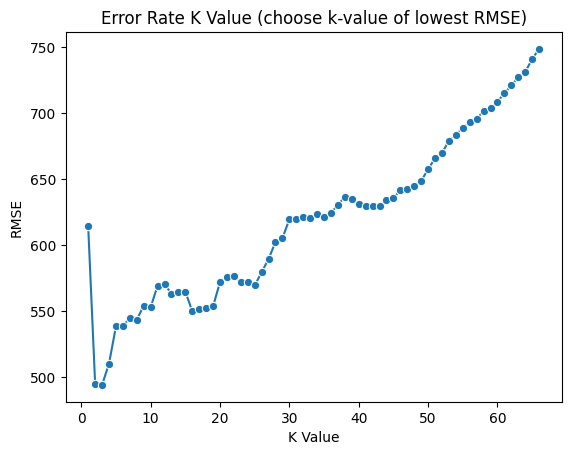

In [15]:
# REGRESSION VERSION
# adjust this to 50 or even 150 if you have lots of data rows
max_iterations = 67

# list to save the error values in the loop
error = []

# the default metric in scikit-learn
metric_selection = "minkowski"
weight_selection = "uniform"
algorithm_selection = "auto"

# Calculating error for K values between 1 and 40
for i in range(1, max_iterations):

    # try with current k-value, train the model and make a test prediction
    knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=i, metric=metric_selection, weights=weight_selection, algorithm=algorithm_selection))
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    
    # save the error value for this k-value
    error.append(np.sqrt(metrics.mean_squared_error(y_test, pred_i)))
    
# plot all the k-values and their error values
sns.lineplot(x=range(1, max_iterations), y=error, marker='o')
plt.title('Error Rate K Value (choose k-value of lowest RMSE)')
plt.xlabel('K Value')
plt.ylabel('RMSE')

# choose best k-value based on metrics
# we have to add +1 to k-value, since argmin() returns an index
# which starts from 0, but k-values start from 1
# print("Based on iterations, best k-value is this:")
k_value = np.argmin(error) + 1
print(k_value)

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    Based on iterations, best K-value is this: 3
  </h2>


</div>

In [16]:
# create the model and train it with the data
# use pipeline to scale the X-values automatically with StandardScaler

# TECHNICALLY you don't even have to use scaler for X (StandardScaler here)
# but it doesn't hurt the model either. it's just more practical
# to have the scaler already implemented in case we try different algorithms on the go
model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k_value, metric=metric_selection))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kneighborsregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(3)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to st

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 5: Error and performance metrics</b>
</h3>
</div>


In [17]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now

# THESE PREDICTIONS ARE IN SCALED FORMAT
predictions = model.predict(X_test)

In [18]:
# MAE = Mean average error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE:")
print(f"{round(mae, 2)} $")

# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE:")
print(f"{round(mse, 2)} $^2")

# RMSE = Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRMSE:")
print(f"{round(rmse, 2)} $")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared:")
print(f"{round(r2, 2)}")

MAE:
419.04 $

MSE:
244288.81 $^2

RMSE:
494.26 $

R-squared:
0.59


/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_11906/2920752686.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


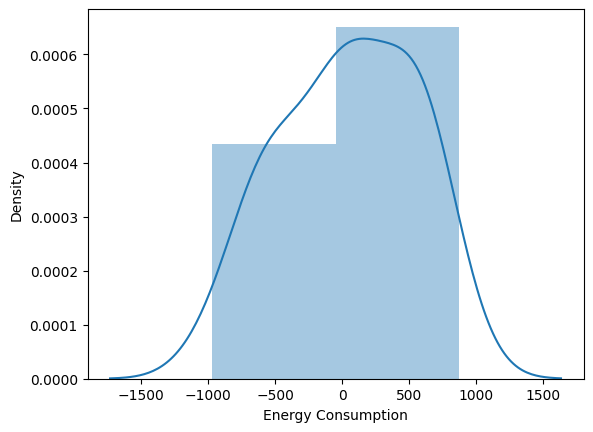

In [19]:
# if the prediction distribution is far from standard normal distritbuion
# then the model is not probably good enough
# distplot is deprecated and will be removed in future seaborn versions
# but not direct replacement has been created so far
sns.distplot((y_test - predictions))
plt.show()
plt.close()

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    OBSERVATION
  </h2>

  <ul style="margin:0 0 0 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li><b>R-squared is 0.59</b>, meaning the model explains about 59% of the variance in the data. This is a moderate result and suggests the model is learning some patterns but there is still scope for improvement.</li>
    <li>The error distribution looks roughly centered around zero, which means the model is not consistently predicting too high or too low.</li>
  </ul>

</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 6: Testing/using the model in practice (inference)</b>
</h3>
</div>


In [20]:
# creating a test row for prediction

test_building_type = "2"
test_square_footage = 24332
test_num_occupants = 10
test_appliances_used = 3
test_avg_temperature = 28.52
test_day_of_week = "0"

tester_row = {
    "Building Type": test_building_type,
    "Square Footage": test_square_footage,
    "Number of Occupants": test_num_occupants,
    "Appliances Used": test_appliances_used,
    "Average Temperature": test_avg_temperature,
    "Day of Week": test_day_of_week
}
# convert to pandas format
tester_row = pd.DataFrame([tester_row])

In [21]:
# get prediction from model
result = model.predict(tester_row)[0]

print()
print("Predicted Energy Consumption:")
print(f"{round(float(result), 2)} kWh")
print("----------------------------")


Predicted Energy Consumption:
3363.82 kWh
----------------------------


---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h1 style="margin:0; color:#f9fafb;">
<b>AI USAGE:</b>
</h1>
</div>


<h3 style='color:orange'>
  <b>Markdown styles</b>
</h3>

---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h1 style="margin:0; color:#f9fafb;">
<b>Ideas for further improvements:</b>
</h1>
</div>


<h5 style='color:orange'>
  <b>Have more rows and columns</b>
</h5>

---

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    🔍 CONCLUSION
  </h2>

  <p style="margin:0 0 8px 0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    The R-squared score of <strong style="color:#85e0e9ff;">0.59</strong> means the model explains about 59% of the variance in the data. This is a moderate result. The error distribution is roughly centered around zero, which means the model is not consistently biased in one direction.
  </p>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    Overall, the model is learning real patterns from the data but there is room for improvement. Trying a different algorithm or tuning hyperparameters could push the R-squared higher.
  </p>

</div>

---

<div style="border: 4px solid #85e0e9ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">

  <h2 style="color: #f9fafb; margin: 0 0 12px 0; font-size: 2em; letter-spacing: 3px;">
    MODEL COMPARISON:
  </h2>

  <p style="color:#e5e7eb; font-size:16px; line-height:1.6; margin: 0 0 14px 0;">
    Comparison of different regression models for the
    <strong style="color:#85e0e9ff;">Energy Consumption</strong>
    prediction task.
  </p>

  <table style="width:100%; border-collapse: collapse; color:#e5e7eb; font-size:16px; line-height:1.5;">
    <thead>
      <tr style="background:#111827;">
        <th style="border:1px solid #85e0e9ff; padding:10px; text-align:left; color:#85e0e9ff;">Model</th>
        <th style="border:1px solid #85e0e9ff; padding:10px; text-align:left; color:#85e0e9ff;">R²</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#1f2933;">
        <td style="border:1px solid #85e0e9ff; padding:10px; color:#e5e7eb;">KNN Regressor</td>
        <td style="border:1px solid #85e0e9ff; padding:10px; color:#e5e7eb;">0.59</td>
      </tr>
      <tr style="background:#111827;">
        <td style="border:1px solid #85e0e9ff; padding:10px;"><strong style="color:#85e0e9ff;">SVR (Polynomial)</strong></td>
        <td style="border:1px solid #85e0e9ff; padding:10px;"><strong style="color:#85e0e9ff;">1.0</strong></td>
      </tr>
    </tbody>
  </table>

  <ul style="margin: 14px 0 0 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li><strong style="color:#85e0e9ff;">SVR </strong> gave the best result with an R² of approximately 1.0, meaning predictions were extremely close to the real values.</li>
    <br>
    <li><strong style="color:#85e0e9ff;">KNN Regressor</strong> showed moderate performance with an R² of 0.59 There is room for improvement.</li>
  </ul>

</div>